# Cartesian Pendulum Clean Example

Minimal notebook for the current workflow: sample contexts with `sample_X_shake_pulse`, simulate with `simulate_cartesian_pendulum_custom`, and evaluate safety with `check_cartesian_safety`. The sampler now uses clean per-variable distribution configs.


In [202]:
from pathlib import Path
import math,random,os,sys, importlib, time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
import data.cartesian_pendulum as cartesian_pendulum_module
importlib.reload(cartesian_pendulum_module)

from data.cartesian_pendulum import (
    CartesianPendulumParams,
    DistributionConfig,
    check_cartesian_safety,
    compute_cartesian_mu_safety_map,
    pivot_shake_pulse_batch,
    sample_X_shake_pulse,
    simulate_cartesian_pendulum_custom,
    compute_cartesian_x_safety_map,
    DistributionConfig
)
import data.plotting_pendulum as plotting_pendulum_module
importlib.reload(plotting_pendulum_module)
from data.plotting_pendulum import (
    plot_cartesian_x_safety_map_shift_panels,
    KDEContourStyle,
    ArrowStyle,
    TextStyle,
    plot_cartesian_x_safety_map, 
    plot_cartesian_mu_safety_map
)

In [210]:
params = CartesianPendulumParams(mass=1.0, length=1.0, gravity=9.81)

num_traj = 10000
T = 10.0
dt = 0.05
t0 = T / 2.0
theta_threshold_deg = 35
time_window = (t0, T)
seed = 21


Empirical safety probability: 0.9770


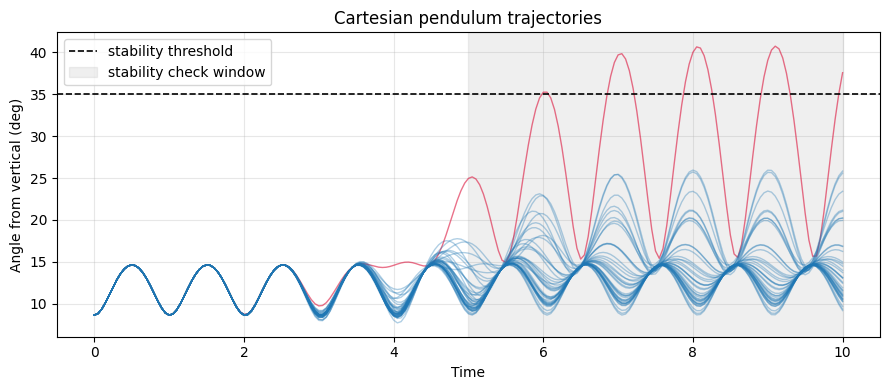

In [211]:
A_config = DistributionConfig(
    kind='beta',
    bounds=(0.0, 0.25),
    alpha=1.0,
    beta=3,
)
omega_config = DistributionConfig(
    kind='beta',
    bounds=(1.0, 5.0),
    alpha=1,
    beta=4,
)

X = sample_X_shake_pulse(
    n_samples=num_traj,
    A_config=A_config,
    omega_config=omega_config,
    sigma_range=1,
    correlation=0,
    t0=t0,
    q=(1.0, 0.0, 0.0),
    a0=(0.0, 0.0, 0.0),
    seed=seed,
)

traj = simulate_cartesian_pendulum_custom(
    params=params,
    t_final=T,
    dt=dt,
    X=X,
    pivot_eval=pivot_shake_pulse_batch,
)

safety_indicator = check_cartesian_safety(
    traj,
    threshold=theta_threshold_deg,
    window=time_window,
)

p_safe = float(np.mean(safety_indicator))
print(f'Empirical safety probability: {p_safe:.4f}')
# print(f'Safe trajectories: {int(np.sum(safety_indicator))}/{len(safety_indicator)}')

plt.figure(figsize=(9, 4))
for i in range(min(40, traj['theta_deg'].shape[0])):
    color = 'tab:blue' if safety_indicator[i] else 'crimson'
    alpha = 0.35 if safety_indicator[i] else 0.6
    plt.plot(traj['t'], traj['theta_deg'][i], color=color, alpha=alpha, linewidth=1.0)

plt.axhline(theta_threshold_deg, color='black', linestyle='--', linewidth=1.2, label='stability threshold')
plt.axvspan(*time_window, color='grey', alpha=0.12, label='stability check window')
plt.xlabel('Time')
plt.ylabel('Angle from vertical (deg)')
plt.title('Cartesian pendulum trajectories')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



In [212]:
res_x = compute_cartesian_x_safety_map(
    params=params,
    t_final=T,
    dt=dt,
    window=time_window,
    threshold=theta_threshold_deg,
    n_grid=30,
    box_limits=((0.0, 0.25), (1.0, 5.0)),
    sigma_range=1,      # same as your sampled data
    n_per_cell=1,       # deterministic-style map
    correlation=0.0,
    t0=t0,
    q=(1.0, 0.0, 0.0),
    a0=(0.0, 0.0, 0.0),
    eta=0.1,
    seed=seed,
)

Empirical safety probability=0.9686 vs threshold 0.9000 (eta=0.1000) -> SAFE


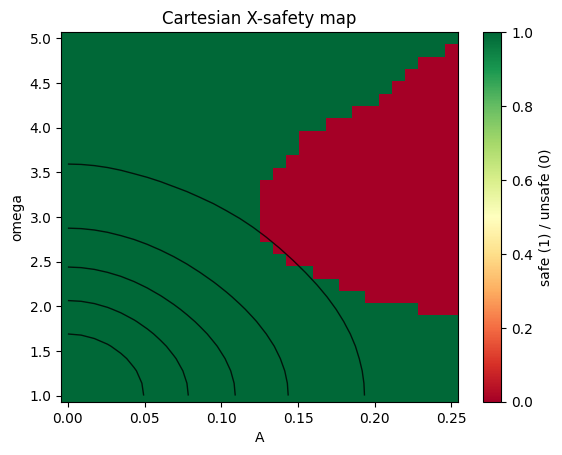

In [213]:
fig, ax = plot_cartesian_x_safety_map(
    res_x,
    title="Cartesian X-safety map",
    A_config=A_config,
    omega_config=omega_config,
    correlation=0.0,
    contour_n_samples=5000,
    contour_levels=5,
    contour_mass=True,
    contour_mass_max=0.9,
    eta=0.1,
)

plt.show()


/home/mzheng/research/Physics-Informed-Hypo-Test/src/data/plotting_pendulum.py:710: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


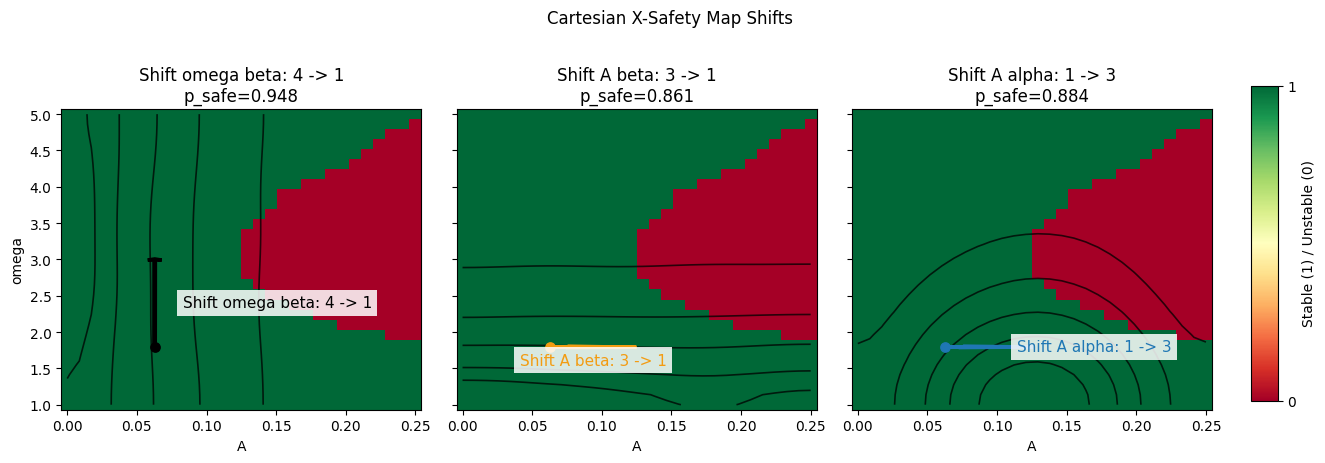

In [ ]:
A_config = DistributionConfig(
    kind="beta",
    bounds=(0.0, 0.25),
    alpha=1.0,
    beta=3.0,
)
omega_config = DistributionConfig(
    kind="beta",
    bounds=(1.0, 5.0),
    alpha=1.0,
    beta=4.0,
)

panel_A_configs = [
    DistributionConfig(kind="beta", bounds=(0.0, 0.25), alpha=1.0, beta=3.0),  # unchanged A
    DistributionConfig(kind="beta", bounds=(0.0, 0.25), alpha=1.0, beta=1.),  # A beta: 3 -> 1
    DistributionConfig(kind="beta", bounds=(0.0, 0.25), alpha=3.0, beta=3.0),  # A alpha: 1 -> 3
]

panel_omega_configs = [
    DistributionConfig(kind="beta", bounds=(1.0, 5.0), alpha=1.0, beta=1.0),  # omega beta: 4 -> 1
    DistributionConfig(kind="beta", bounds=(1.0, 5.0), alpha=1.0, beta=4.0),  # unchanged omega
    DistributionConfig(kind="beta", bounds=(1.0, 5.0), alpha=1.0, beta=4.0),  # unchanged omega
]

contour_style = KDEContourStyle(levels=5, mass=True, mass_max=0.9, color="black", alpha=0.75, linewidth=1.2)

arrow_style = ArrowStyle(
    scale=1.0,
    scale_each=(1.0, 1.0, 1.0),
    head_width=0.02,
    head_length=0.05,
    head_width_each=(0.01, 0.02, 0.02),
    head_length_each=(0.015, 0.05, 0.05),
    linewidth=2.5,
    point_size=45,
)

text_style = TextStyle(
    show=True,
    offset_each=((0.02, 0.08), (0.02, 0.08), (0.02, 0.08)),
    side_each=("right", "bottom", "right"),
    fontsize=11,
    bbox_alpha=0.85,
)

fig, axes = plot_cartesian_x_safety_map_shift_panels(
    res_x,
    # labels=[
    #     "Shift omega beta: 4 -> 1",
    #     "Shift A beta: 3 -> 1",
    #     "Shift A alpha: 1 -> 3",
    # ],
    A_config=A_config,
    omega_config=omega_config,
    correlation=0.0,
    panel_A_configs=panel_A_configs,
    panel_omega_configs=panel_omega_configs,
    contour_n_samples=10000,
    contour_style=contour_style,
    arrow_style=arrow_style,
    text_style=text_style,
    title_prefix="Cartesian X-Safety Map Shifts",
    figsize=(13.5, 4.5),
)

plt.show()

/home/mzheng/research/Physics-Informed-Hypo-Test/src/data/plotting_pendulum.py:710: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


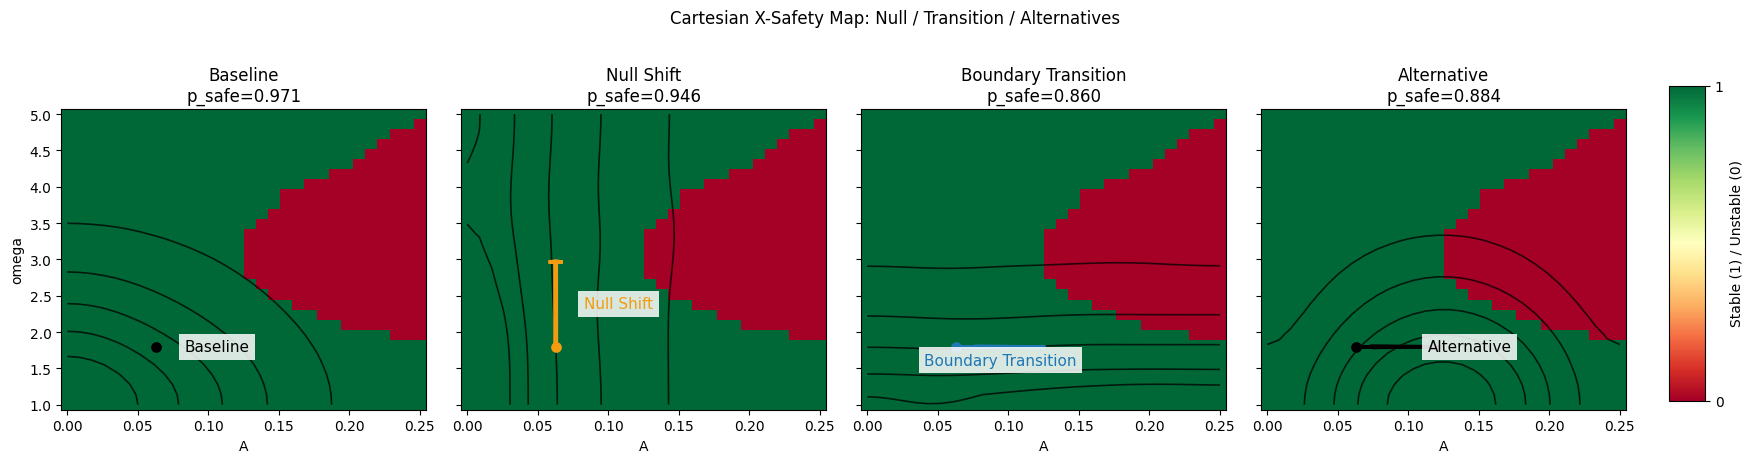

In [225]:
from data.cartesian_pendulum import DistributionConfig
from data.plotting_pendulum import (
    plot_cartesian_x_safety_map_shift_panels,
    KDEContourStyle,
    ArrowStyle,
    TextStyle,
)

A_config = DistributionConfig(
    kind="beta",
    bounds=(0.0, 0.25),
    alpha=1.0,
    beta=3.0,
)
omega_config = DistributionConfig(
    kind="beta",
    bounds=(1.0, 5.0),
    alpha=1.0,
    beta=4.0,
)

# 4 panels: baseline + 3 shifted alternatives
panel_A_configs = [
    DistributionConfig(kind="beta", bounds=(0.0, 0.25), alpha=1.0, beta=3.0),  # baseline
    DistributionConfig(kind="beta", bounds=(0.0, 0.25), alpha=1.0, beta=3.0),  # unchanged A
    DistributionConfig(kind="beta", bounds=(0.0, 0.25), alpha=1.0, beta=1.0),  # A beta: 3 -> 1
    DistributionConfig(kind="beta", bounds=(0.0, 0.25), alpha=3.0, beta=3.0),  # A alpha: 1 -> 3
]

panel_omega_configs = [
    DistributionConfig(kind="beta", bounds=(1.0, 5.0), alpha=1.0, beta=4.0),  # baseline
    DistributionConfig(kind="beta", bounds=(1.0, 5.0), alpha=1.0, beta=1.0),  # omega beta: 4 -> 1
    DistributionConfig(kind="beta", bounds=(1.0, 5.0), alpha=1.0, beta=4.0),  # unchanged omega
    DistributionConfig(kind="beta", bounds=(1.0, 5.0), alpha=1.0, beta=4.0),  # unchanged omega
]

labels = [
    "Baseline",
    r"Null Shift",
    r"Boundary Transition",
    r"Alternative",
]

contour_style = KDEContourStyle(
    levels=5,
    mass=True,
    mass_max=0.9,
    color="black",
    alpha=0.75,
    linewidth=1.2,
)

arrow_style = ArrowStyle(
    scale=1.0,
    scale_each=(1.0, 1.0, 1.0, 1.0),
    linewidth=2.5,
    head_width=0.02,
    head_length=0.05,
    head_width_each=(0.0, 0.01, 0.02, 0.02),     # no arrow head for null panel
    head_length_each=(0.0, 0.015, 0.05, 0.05),
    point_size=45,
)

text_style = TextStyle(
    show=True,
    offset_each=((0.02, 0.08), (0.02, 0.08), (0.02, 0.08), (0.02, 0.08)),
    side_each=("right", "right", "bottom", "right"),
    fontsize=11,
    bbox_alpha=0.85,
)

fig, axes = plot_cartesian_x_safety_map_shift_panels(
    res_x,
    labels=labels,
    A_config=A_config,
    omega_config=omega_config,
    correlation=0.0,
    panel_A_configs=panel_A_configs,
    panel_omega_configs=panel_omega_configs,
    contour_n_samples=10000,
    contour_style=contour_style,
    arrow_style=arrow_style,
    text_style=text_style,
    title_prefix="Cartesian X-Safety Map: Null / Transition / Alternatives",
    figsize=(18, 4.5),
    colors = ["black", "#f39c12", "#1f77b4",'black']
)

plt.show()
